# Evaluation & Case Studies

**Navigation**: [← Previous: Live Charts](05_live_charts.ipynb) | [Next: Project Overview →](index.md)

Calibration analysis, model–DLS disagreement, and limitations.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'

from sklearn.metrics import brier_score_loss
import joblib
lgbm = joblib.load(DATA_DIR / 'lgbm_model.joblib')
feature_cols = [
    'runs_scored', 'wickets_lost', 'balls_remaining', 'wickets_remaining',
    'runs_required', 'runs_required_per_ball', 'current_run_rate',
    'overs_completed', 'phase_powerplay', 'phase_death',
]
val_df = pd.read_csv(DATA_DIR / 'odi_training_sample.csv')
val_matches = val_df['match_idx'].unique()[-80:]
val_df = val_df[val_df['match_idx'].isin(val_matches)]
val_df = val_df.copy()
val_df['ml_prob'] = lgbm.predict_proba(val_df[feature_cols])[:, 1]


## Calibration (reliability diagram)

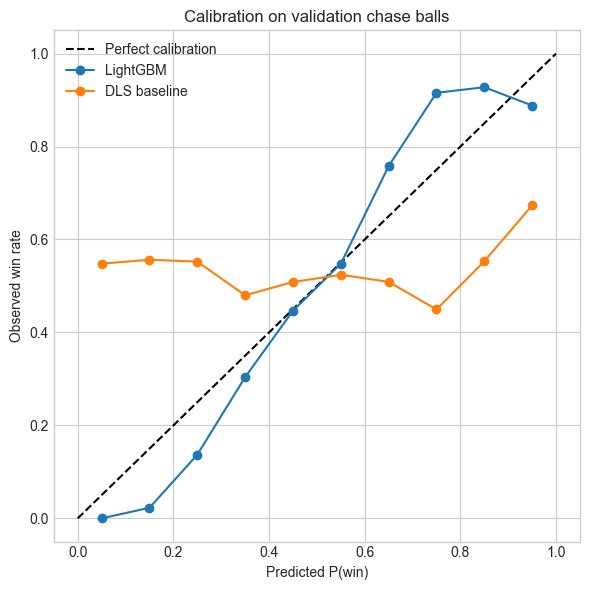

In [2]:
def reliability_curve(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    mids, obs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        mids.append((lo + hi) / 2)
        obs.append(y_true[mask].mean())
    return np.array(mids), np.array(obs)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
for name, col in [('LightGBM', 'ml_prob'), ('DLS baseline', 'dls_prob')]:
    mids, obs = reliability_curve(val_df['batting_team_won'].values, val_df[col].values)
    ax.plot(mids, obs, 'o-', label=name)
ax.set_xlabel('Predicted P(win)')
ax.set_ylabel('Observed win rate')
ax.set_title('Calibration on validation chase balls')
ax.legend()
plt.tight_layout()
fig.savefig(PROJ_DIR / 'figures' / '06_calibration.png', dpi=120)
plt.show()


## Where ML and DLS disagree most

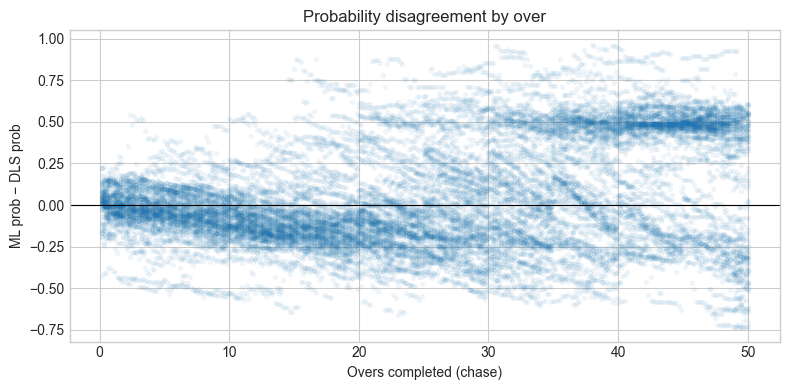

In [3]:
val_df['prob_diff'] = val_df['ml_prob'] - val_df['dls_prob']
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(val_df['overs_completed'], val_df['prob_diff'], alpha=0.05, s=8)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Overs completed (chase)')
ax.set_ylabel('ML prob − DLS prob')
ax.set_title('Probability disagreement by over')
plt.tight_layout()
plt.show()


## Case-study summary

In [4]:
cases = []
for fname in sorted(SAMPLE_DIR.glob('*.json')):
    doc = load_cricsheet_json(fname)
    meta = match_metadata(doc)
    states = build_game_states(doc)
    states['ml_prob'] = lgbm.predict_proba(states[feature_cols])[:, 1]
    cases.append({
        'Match': fname.stem,
        'Event': meta['event'],
        'Winner': meta['winner'],
        'Max ML P(win)': round(states['ml_prob'].max(), 3),
        'Min ML P(win)': round(states['ml_prob'].min(), 3),
        'Final ML P(win)': round(states['ml_prob'].iloc[-1], 3),
    })
pd.DataFrame(cases)


,Match,Event,Winner,Max ML P(win),Min ML P(win),Final ML P(win)
0,2011_wc_eng_ire_upset,ICC Cricket World Cup,Ireland,0.717,0.289,0.644
1,2011_wc_qf_ind_aus,ICC Cricket World Cup Quarter-Final,India,0.647,0.398,0.491
2,2019_wc_final_eng_nz,ICC Cricket World Cup Final,England,0.973,0.018,0.906


## Limitations & further reading

- Simplified DLS tables; no rain-adjusted par scores mid-match
- No player quality, venue, or pitch effects
- ODI only; T20 and Test need separate resource structures
- Further reading: Duckworth & Lewis (1998), Jayadevan (VJD method), ESPNcricinfo win-probability models

---

**Navigation**: [← Previous: Live Charts](05_live_charts.ipynb) | [Next: Project Overview →](index.md)
